<a href="https://colab.research.google.com/github/tarannump096-cpu/NLP/blob/main/Airbnb_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor

In [6]:
try:
    df = pd.read_csv("/content/Airbnb_Data.csv", engine='python', nrows=5)
    print("Successfully read first 5 rows:")
    print(df.head())
except Exception as e:
    print(f"Could not read even 5 rows. Error: {e}")
    print("This indicates the CSV file might be corrupted or severely truncated. Please check the integrity of '/content/Airbnb_Data.csv'.")

Successfully read first 5 rows:
         id  log_price property_type        room_type  \
0   6901257   5.010635     Apartment  Entire home/apt   
1   6304928   5.129899     Apartment  Entire home/apt   
2   7919400   4.976734     Apartment  Entire home/apt   
3  13418779   6.620073         House  Entire home/apt   
4   3808709   4.744932     Apartment  Entire home/apt   

                                           amenities  accommodates  bathrooms  \
0  {"Wireless Internet","Air conditioning",Kitche...             3        1.0   
1  {"Wireless Internet","Air conditioning",Kitche...             7        1.0   
2  {TV,"Cable TV","Wireless Internet","Air condit...             5        1.0   
3  {TV,"Cable TV",Internet,"Wireless Internet",Ki...             4        1.0   
4  {TV,Internet,"Wireless Internet","Air conditio...             2        1.0   

   bed_type cancellation_policy  cleaning_fee  ...   latitude   longitude  \
0  Real Bed              strict          True  ...  40.696524

In [8]:
df.drop(['id', 'name', 'last_review'], axis=1, inplace=True)

In [14]:
df['number_of_reviews'] = df['number_of_reviews'].fillna(0)

In [10]:
print(df.columns)

Index(['log_price', 'property_type', 'room_type', 'amenities', 'accommodates',
       'bathrooms', 'bed_type', 'cancellation_policy', 'cleaning_fee', 'city',
       'description', 'first_review', 'host_has_profile_pic',
       'host_identity_verified', 'host_response_rate', 'host_since',
       'instant_bookable', 'latitude', 'longitude', 'neighbourhood',
       'number_of_reviews', 'review_scores_rating', 'thumbnail_url', 'zipcode',
       'bedrooms', 'beds'],
      dtype='object')


In [15]:
le = LabelEncoder()

df['neighbourhood'] = le.fit_transform(df['neighbourhood'])
df['room_type'] = le.fit_transform(df['room_type'])

In [17]:
df = df[df['log_price'] > 0]
df['log_price'] = np.log1p(df['log_price'])

In [19]:
features = [
    'neighbourhood',
    'room_type',
    'number_of_reviews'
]

X = df[features]
y = df['log_price']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [22]:
y_pred = model.predict(X_test)

In [23]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 0.010592424130854816


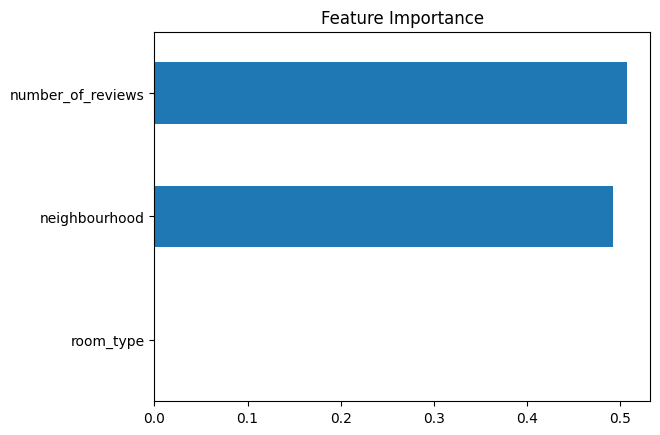

In [24]:
importance = pd.Series(model.feature_importances_, index=features)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()